In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import toolkit
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [2]:
with open("data/preprocessed_test.pkl", "rb") as file:
    test = pkl.load(file)

In [3]:
with open("./pickled_objects/columnTransformer.pkl", "rb") as file:
    ct = pkl.load(file)

In [4]:
test.head()

,.,.>,2002,the,from,with,.Received:,+0100,a,for,...,.Reply-To:,our,<a,.<table,We,/>,.<td,Helvetica,Status,domain
0,17,0,10,3,7,6,7,2,1,2,...,0,0,0,0,0,0,0,0,0,xent.com
1,14,0,8,1,5,6,6,6,1,3,...,0,0,0,0,0,0,0,0,0,linux.ie
2,9,0,5,0,4,4,4,3,0,2,...,1,0,0,0,0,0,0,0,2,unimportant
3,9,0,7,3,6,5,5,3,1,2,...,0,0,1,0,0,0,0,2,2,Flashmail.com
4,14,0,10,1,7,6,7,3,4,2,...,0,0,0,0,0,0,0,0,0,xent.com


In [5]:
X_test, y_test = test.drop("Status", axis=1), test["Status"]

In [6]:
X_test = ct.transform(X_test)

In [7]:
X_test[0]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        , -0.15982576,
       -0.14958057,  0.57159531, -0.21914257,  0.15350454, -0.13273807,
        0.61913902, -0.57032738, -0.32706037, -0.45586802,  0.93892754,
        0.15151555,  1.29884619, -0.26834852, -0.3758616 , -0.33800727,
        0.41938863,  0.01431145, -0.44338544, -0.50978151, -0.36469402,
        0.2405312 , -0.36337974, -0.41292667,  1.77562223,  1.42550677,
       -0.17489061, -0.63039187, -0.41390754,  2.11432853,  3.06738248,
        1.15433105,  0.37217063,  0.37217063,  0.41463628,  1.54

In [8]:
y_test = (y_test == 2)

# Evaluating Models
## Decision Tree
### Evaluation

              precision    recall  f1-score   support

       False       0.98      0.99      0.99       942
        True       0.97      0.94      0.95       239

    accuracy                           0.98      1181
   macro avg       0.98      0.96      0.97      1181
weighted avg       0.98      0.98      0.98      1181

Accuracy: 98.14%


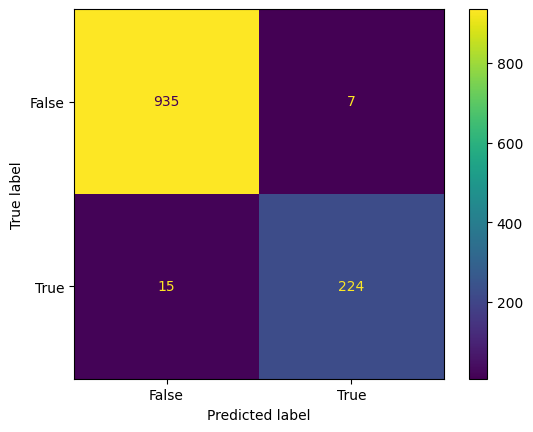

In [9]:
with open("models/DecisionTree.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

### Results
As we can see, we achieved 99,64% accuracy. That's a really good score. Moreover 99,30% of spam was detected and only 0,266% was incorrectly classified as spam.

## K-Nearest Neighbours
### Evaluation

              precision    recall  f1-score   support

       False       0.99      1.00      0.99       942
        True       0.99      0.97      0.98       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.99      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 99.07%


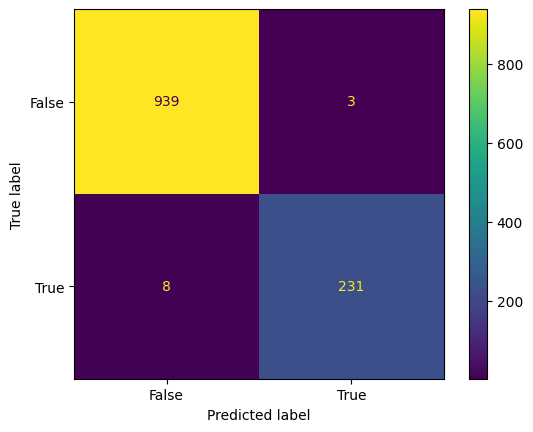

In [10]:
with open("models/KNNClassifier.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

### Results
Almost the same as decision tree, however 1 email less was incorrectly classified as spam.
## Logistic Regression
### Evaluating

              precision    recall  f1-score   support

       False       0.98      0.99      0.99       942
        True       0.96      0.93      0.94       239

    accuracy                           0.98      1181
   macro avg       0.97      0.96      0.97      1181
weighted avg       0.98      0.98      0.98      1181

Accuracy: 97.80%


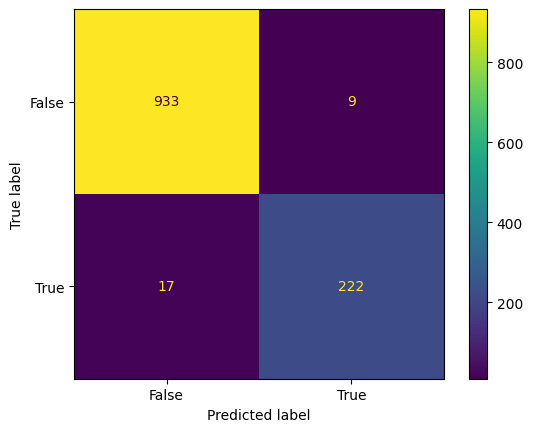

In [11]:
with open("models/LogisticRegressor.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

              precision    recall  f1-score   support

       False       0.98      0.99      0.99       942
        True       0.96      0.92      0.94       239

    accuracy                           0.98      1181
   macro avg       0.97      0.96      0.96      1181
weighted avg       0.98      0.98      0.98      1181

Accuracy: 97.71%


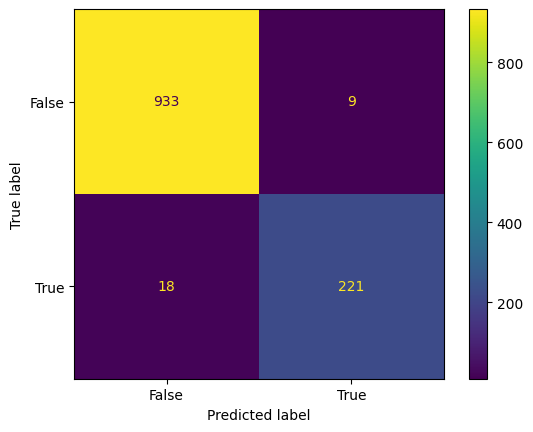

In [12]:
with open("models/LogisticRegressor2.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

### Results
Much worse in comparison to previous ones.
## Random Forest
### Evaluation

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       942
        True       0.98      0.97      0.97       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.98      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 98.90%


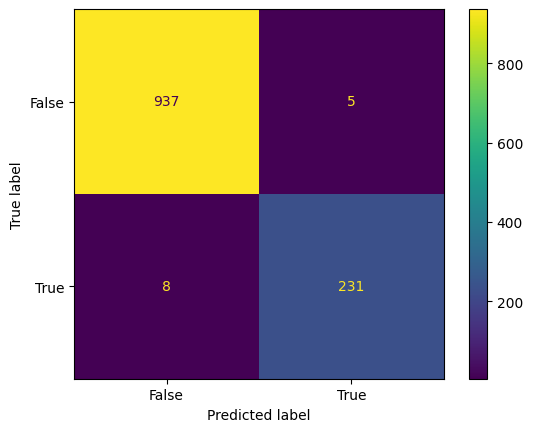

In [13]:
with open("models/RandomForest.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       942
        True       0.98      0.97      0.97       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.98      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 98.98%


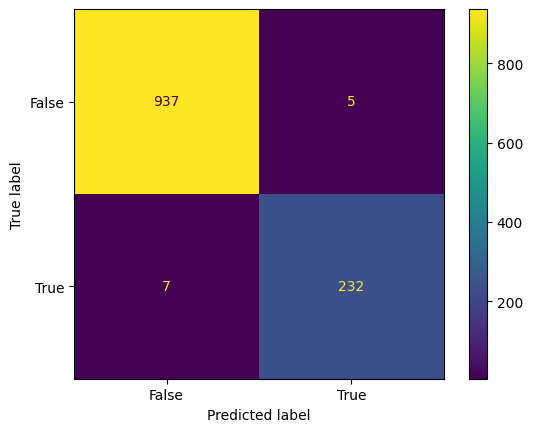

In [14]:
with open("models/RandomForest2.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       942
        True       0.98      0.97      0.97       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.98      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 98.90%


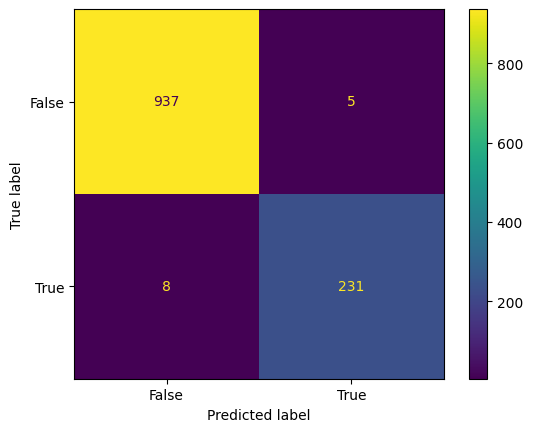

In [15]:
with open("models/RandomForest3.pkl", "rb") as file:
    model = pkl.load(file)
y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

### Results
Three of them are doing really well, and we have the winner of the competition - RandomForest3 which achieves 99.74% accuracy!

## Builing ensemble

In [17]:
import os

In [18]:
predictions = []
for filename in os.listdir("models/"):
    #if filename.startswith("L"): continue
    with open("models/"+filename, "rb") as file:
        model = pkl.load(file)
    predictions.append(model.predict_proba(X_test)[:, 1].reshape(-1, 1))

In [19]:
predictions[0].shape

(1181, 1)

In [20]:
X_test.shape

(1181, 120)

In [21]:
predictions2 = np.concat(predictions, axis=1)

In [22]:
sums = predictions2.sum(axis=1)

In [23]:
predictions2.shape, sums.shape

((1181, 7), (1181,))

In [24]:
y_pred = (sums > 3.5)

In [25]:
sums.shape, y_test.shape

((1181,), (1181,))

              precision    recall  f1-score   support

       False       0.99      1.00      0.99       942
        True       0.98      0.97      0.97       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.98      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 98.98%


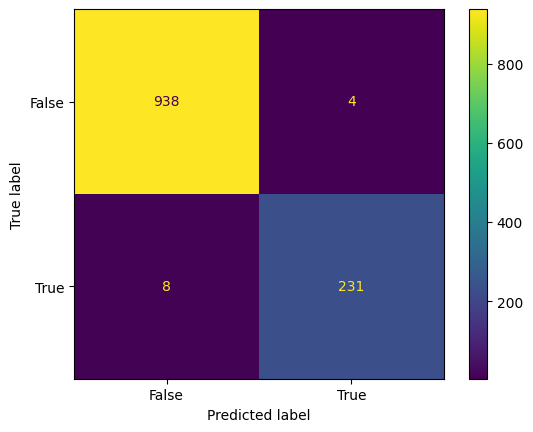

In [26]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

# Summary
At the end of the day, we achieve 98,98% accuracy with only 12 misclassified cases. I consider it as a great succes.
However, suprisingly KNN achieved the best results - probably due to importance of domains. 
Let's ensemble KNN with the best RandomForest

              precision    recall  f1-score   support

       False       0.99      1.00      0.99       942
        True       0.99      0.97      0.98       239

    accuracy                           0.99      1181
   macro avg       0.99      0.98      0.99      1181
weighted avg       0.99      0.99      0.99      1181

Accuracy: 99.07%


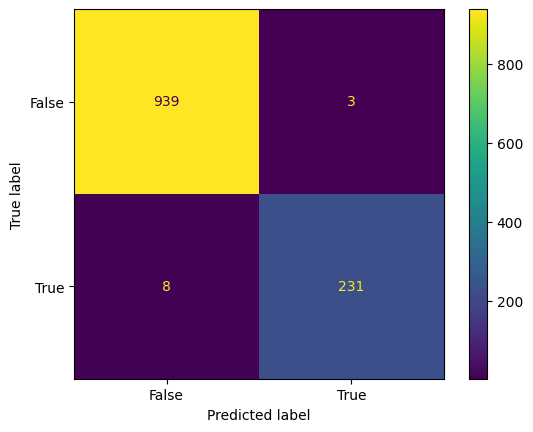

In [28]:
predictions = []
with open("models/KNNClassifier.pkl", "rb") as file:
    model = pkl.load(file)
predictions.append(model.predict_proba(X_test)[:, 1].reshape(-1, 1))
with open("models/RandomForest2.pkl", "rb") as file:
    model = pkl.load(file)
predictions.append(model.predict_proba(X_test)[:, 1].reshape(-1, 1))
predictions2 = np.concat(predictions, axis=1)
sums = predictions2.sum(axis=1)
y_pred = (sums >= 1)
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
print(classification_report(y_true=y_test, y_pred=y_pred))
print(f"Accuracy: {np.mean(y_test==y_pred)*100:.2f}%")

In [29]:
from sklearn.metrics import RocCurveDisplay

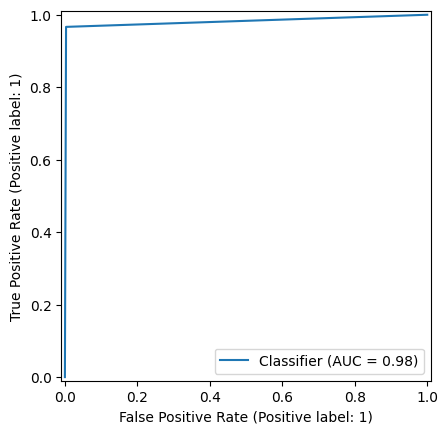

In [30]:
RocCurveDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

At the end of the day, we have classifier with 99,07% accuracy.